Debug info for heuristic:
Sample StartTime original_ids: ['spout*47_', 'sp2*31_', 'spout*11_', 'sp2*43_', 'spout*4_']
Sample EndTime original_ids: ['spout*8_', 'spout*13_', 'sp2*10_', 'sp2*38_', 'sp2*40_']
StartTime unique original_ids: 30254
EndTime unique original_ids: 30254
Merged data count: 30257
EmitRate per cycle for heuristic:
    start_cycle  EmitRate
0           1.0       1.0
1           2.0       1.0
2           3.0       1.0
3           4.0       3.0
4           5.0       3.0
5           6.0       6.0
6           7.0       6.0
7           8.0       6.0
8           9.0       6.0
9          10.0       6.0
10         11.0      10.0
11         12.0      10.0
12         13.0      10.0
13         14.0      10.0
14         15.0      10.0
15         16.0      10.0
16         17.0      15.0
17         18.0      15.0
18         19.0      15.0
19         20.0      15.0
20         21.0      15.0
21         22.0      20.0
22         23.0      20.0
23         24.0      20.0
24         25

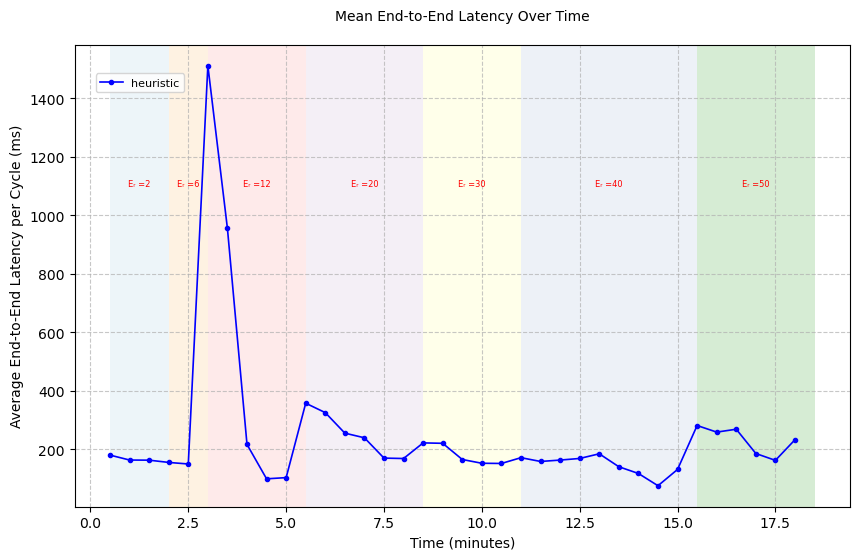

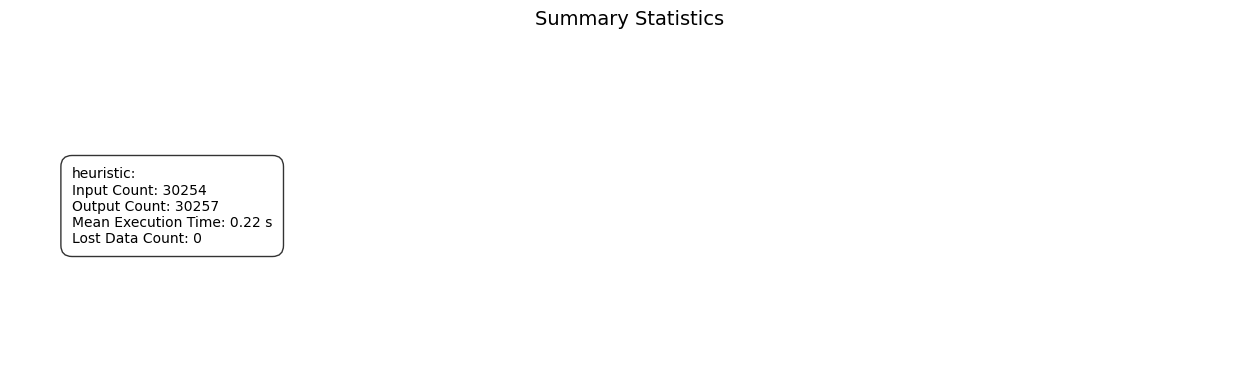

In [2]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import numpy as np

# Define colors for EmitRate regions
emit_rate_colors = [
    '#a6cee3', '#fdbf6f', '#fb9a99', '#cab2d6', '#ffff99', '#a6bddb', '#33a02c'
]

# Approach color mapping
approach_color_map = {
    "heuristic": "blue", "globalAdaptationOnly": "red",
    "noLocal_noGlobal": "purple", "storm_replication": "green"
}

def plot_mean_execution_time(
    file_patterns=['executionTime_*.csv'],
    cycle_duration_seconds=30,
    cycle_start=1,
    cycle_end=40
):
    approaches = []
    
    for file_pattern in file_patterns:
        file_list = glob.glob(file_pattern)
        if not file_list:
            print(f"No files found matching '{file_pattern}'. Skipping.")
            continue
        
        for file_name in file_list:
            approach_name = os.path.basename(file_name).split('executionTime_')[1].split('.csv')[0]
            df = pd.read_csv(file_name)
            
            df['MessageID'] = df['MessageID'].astype(str)
            df['StartTime'] = pd.to_numeric(df['StartTime'], errors='coerce')
            df['EndTime'] = pd.to_numeric(df['EndTime'], errors='coerce')
            df['cycle'] = pd.to_numeric(df['cycle'], errors='coerce')
            df['EmitRate'] = pd.to_numeric(df['EmitRate'], errors='coerce')
            
            df_start = df[df['StartTime'].notnull()].copy()
            df_end = df[df['EndTime'].notnull()].copy()
            
            # FIXED: Correct original_id extraction
            # For StartTime rows: MessageID like "sp4*4_" -> original_id: "sp4*4_"
            # For EndTime rows: MessageID like "sp4*4_b1b2" -> original_id: "sp4*4_"
            
            def extract_original_id(message_id):
                """Extract the original ID from MessageID"""
                if '_' in message_id:
                    parts = message_id.split('_')
                    return parts[0] + '_'
                return message_id
            
            df_start['original_id'] = df_start['MessageID'].apply(extract_original_id)
            df_end['original_id'] = df_end['MessageID'].apply(extract_original_id)
            
            # Filter out non-numeric original IDs (but keep the format like "sp4*4_")
            # The original code was checking if original_id without '_' is numeric, but that's wrong
            # We should keep all valid message IDs that follow the expected pattern
            
            print(f"Debug info for {approach_name}:")
            print(f"Sample StartTime original_ids: {df_start['original_id'].head().tolist()}")
            print(f"Sample EndTime original_ids: {df_end['original_id'].head().tolist()}")
            print(f"StartTime unique original_ids: {df_start['original_id'].nunique()}")
            print(f"EndTime unique original_ids: {df_end['original_id'].nunique()}")
            
            # Remove duplicates
            df_start = df_start.drop_duplicates(subset=['MessageID'])
            df_end = df_end.drop_duplicates(subset=['MessageID'])
            
            # Merge on original_id
            merged = pd.merge(
                df_start[['original_id', 'StartTime', 'cycle', 'EmitRate']],
                df_end[['original_id', 'EndTime']],
                on='original_id',
                how='inner'
            )
            
            print(f"Merged data count: {len(merged)}")
            
            if merged.empty:
                print(f"No data for {approach_name} after merge.")
                # Debug: Check what's in each dataset
                start_ids = set(df_start['original_id'].head(10))
                end_ids = set(df_end['original_id'].head(10))
                print(f"Sample StartTime IDs: {start_ids}")
                print(f"Sample EndTime IDs: {end_ids}")
                print(f"Intersection: {start_ids.intersection(end_ids)}")
                continue
            
            merged['ExecutionTime'] = merged['EndTime'] - merged['StartTime']
            overall_mean_execution_time_s = merged['ExecutionTime'].mean() / 1000
            
            input_count = df_start['original_id'].nunique()
            output_count = len(merged)
            
            start_ids = set(df_start['original_id'])
            end_ids = set(df_end['original_id'])
            lost_data = list(start_ids - end_ids) + list(end_ids - start_ids)
            lost_data_count = len(lost_data)
            
            df_lost = pd.DataFrame({'LostData': lost_data})
            df_lost.to_csv(f'lost_data_{approach_name}.csv', index=False)
            
            merged.rename(columns={'cycle': 'start_cycle'}, inplace=True)
            
            if cycle_start is not None:
                merged = merged[merged['start_cycle'] >= cycle_start]
            if cycle_end is not None:
                merged = merged[merged['start_cycle'] <= cycle_end]
            
            if merged.empty:
                print(f"No data for {approach_name} after cycle filtering.")
                continue
            
            mean_execution_time = merged.groupby('start_cycle', as_index=False)['ExecutionTime'].mean()
            mean_execution_time['TimeMinutes'] = mean_execution_time['start_cycle'] * (cycle_duration_seconds / 60.0)
            
            emit_rate_by_cycle = merged.groupby('start_cycle', as_index=False)['EmitRate'].first()
            mean_execution_time = pd.merge(mean_execution_time, emit_rate_by_cycle, on='start_cycle')
            
            # Debug: Print EmitRate per cycle
            print(f"EmitRate per cycle for {approach_name}:")
            print(mean_execution_time[['start_cycle', 'EmitRate']])
            
            mean_execution_time['Rate_Change'] = mean_execution_time['EmitRate'].ne(mean_execution_time['EmitRate'].shift())
            mean_execution_time['Segment_ID'] = mean_execution_time['Rate_Change'].cumsum()
            
            segments = []
            for seg_id in mean_execution_time['Segment_ID'].unique():
                seg_data = mean_execution_time[mean_execution_time['Segment_ID'] == seg_id]
                if not seg_data.empty:
                    rate_value = seg_data['EmitRate'].iloc[0]
                    c0 = seg_data['start_cycle'].iloc[0]
                    c1 = seg_data['start_cycle'].iloc[-1]
                    start_min = c0 * (cycle_duration_seconds / 60.0)  # Start at cycle start
                    end_min = (c1 + 1) * (cycle_duration_seconds / 60.0)  # End at next cycle start
                    segments.append((start_min, end_min, rate_value))
            
            print(f"Segments for {approach_name}: {[(start, end, rate) for start, end, rate in segments]}")
            
            approaches.append({
                'name': approach_name,
                'mean_exec_time': mean_execution_time,
                'segments': segments,
                'input_count': input_count,
                'output_count': output_count,
                'overall_mean_s': overall_mean_execution_time_s,
                'lost_count': lost_data_count,
                'lost_data': lost_data
            })
    
    if not approaches:
        print("No data to plot.")
        return
    
    # Create the main execution time plot
    plt.figure(figsize=(10, 6))
    
    for idx, approach in enumerate(approaches):
        met = approach['mean_exec_time']
        color = approach_color_map.get(approach['name'], 'gray')
        
        plt.plot(
            met['TimeMinutes'],
            met['ExecutionTime'],
            marker='o',
            color=color,
            label=approach['name'],
            markersize=3,
            linewidth=1.2
        )
        
        if idx == 0:
            for seg_idx, (start_min, end_min, rate) in enumerate(approach['segments']):
                seg_color = emit_rate_colors[seg_idx % len(emit_rate_colors)]
                plt.axvspan(start_min, end_min, facecolor=seg_color, alpha=0.2)
                plt.text(
                    (start_min + end_min) / 2,
                    plt.ylim()[1] * 0.70,
                    #met['ExecutionTime'].max() * 2,
                    f"Eᵣ ={int(rate)*2}",
                    ha='center',
                    va='center',
                    fontsize=6,
                    color='red'
                )
    
   # plt.title("Comparison of Mean End-to-End Latency Across Baselines\n", fontsize=10)
    plt.title("Mean End-to-End Latency Over Time\n", fontsize=10)
    plt.xlabel("Time (minutes)", fontsize=10)
    plt.ylabel("Average End-to-End Latency per Cycle (ms)", fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=8,bbox_to_anchor=(0.02, 0.95),loc='upper left')
    
    approach_names = [a['name'] for a in approaches]
    filename_base = "-".join(approach_names) + "_meanExecutionTime"
    #plt.savefig(f"{filename_base}.png", dpi=200, bbox_inches='tight')
    plt.savefig("latencySummaryPlot.png", dpi=200, bbox_inches='tight')
    plt.show()
    
    # Create a separate figure for the summary tables
    fig, ax = plt.subplots(figsize=(16, 4))
    ax.axis('off')  # Turn off the axes
    
    # Position the summary tables
    num_approaches = len(approaches)
    table_spacing = 0.9 / num_approaches  # Use 90% of width with proper spacing
    
    for idx, approach in enumerate(approaches):
        text = (
            f"{approach['name']}:\n"
            f"Input Count: {approach['input_count']}\n"
            f"Output Count: {approach['output_count']}\n"
            f"Mean Execution Time: {approach['overall_mean_s']:.2f} s\n"
            f"Lost Data Count: {approach['lost_count']}"
        )
        
        # Position each table with better spacing
        x_pos = 0.05 + (idx * table_spacing)
        ax.text(
            x_pos,
            0.5,
            text,
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='center',
            horizontalalignment='left',
            bbox=dict(facecolor='white', edgecolor='black', alpha=0.8, boxstyle='round,pad=0.8')
        )
    
    plt.title("Summary Statistics", fontsize=14, pad=20)
    
    # Save the summary table as a separate image
    summary_filename = "-".join(approach_names) + "_summary_tables"
    plt.savefig("table"+f"{summary_filename}.png", dpi=200, bbox_inches='tight')
    
    plt.show()

if __name__ == "__main__":
    plot_mean_execution_time(
        file_patterns=['executionTime_*.csv'],
        cycle_duration_seconds=30,
        cycle_start=1,
        cycle_end=50
    )